# Paper[jcise]: Modeling Distributed Situation Awareness

This notebook used for paper `Irshad, L., & Hulse, D. (2025). Toward Early Design Modeling and Simulation of Distributed Situation Awareness. Journal of Computing and Information Science in Engineering, 25(6), 061001.`

The taxiway model has three main agents:
- Helicopter, which lands and takes off from a helipad
- Aircraft, which lands at a runway, taxis to a gate, and takes off from a runway (and may be UAVs or Piloted Aircraft)
- ATC, which coordinates operations

These agents interact via the flows:
- Ground, a MultiFlow tracking the map as well as agent assignments/allocations
- Location, a MultiFlow tracking the position/velocity of each route on the map, and
- Requests, a CommsFlow tracking the messages sent between the ATC and the Aircraft/Helicopters

```
Copyright © 2024, United States Government, as represented by the Administrator of the National Aeronautics and Space Administration. All rights reserved.

The “"Fault Model Design tools - fmdtools version 2"” software is licensed under the Apache License, Version 2.0 (the "License"); you may not use this file except in compliance with the License. You may obtain a copy of the License at http://www.apache.org/licenses/LICENSE-2.0. 

Unless required by applicable law or agreed to in writing, software distributed under the License is distributed on an "AS IS" BASIS, WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied. See the License for the specific language governing permissions and limitations under the License.
```

In [2]:
from model_main import taxiway_model, create_fault_scen_metrics

from fmdtools.sim import propagate as prop
import networkx as nx
from model_common import plot_tstep, plot_course

In [3]:
import pandas as pd

In [4]:
from fmdtools.define.architecture.function import FunctionArchitectureTypeGraph

In [5]:
mdl = taxiway_model()

In [6]:
tg = FunctionArchitectureTypeGraph(mdl)

In [7]:
tg.set_edge_labels(title='')

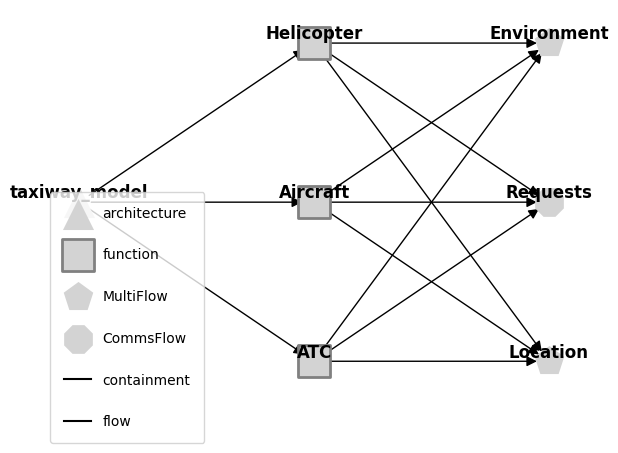

In [8]:
fig, ax = tg.draw(figsize=(7,5), withlegend=True, legend_bbox=(0, .2))

In [9]:
fig.savefig("outputs_paper_jcise_dsa/modelstructure.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [10]:
mdl.flows['location']

location Location
- s=LocationState(x=30.0, y=25.0, xd=0.0, yd=0.0, speed=0.0, stage='flight', mode='standby')
LOCALS:
- ma1=(s=(x=10.0, y=20.0, xd=0.0, yd=0.0, speed=0.0, stage='takeoff', mode='standby'))
- ma2=(s=(x=30.0, y=25.0, xd=0.0, yd=0.0, speed=0.0, stage='flight', mode='standby'))
- ma3=(s=(x=30.0, y=25.0, xd=0.0, yd=0.0, speed=0.0, stage='flight', mode='standby'))
- ua1=(s=(x=45.0, y=-5.0, xd=0.0, yd=0.0, speed=0.0, stage='park', mode='standby'))
- ua2=(s=(x=30.0, y=25.0, xd=0.0, yd=0.0, speed=0.0, stage='flight', mode='standby'))
- ua3=(s=(x=30.0, y=25.0, xd=0.0, yd=0.0, speed=0.0, stage='flight', mode='standby'))
- h1=(s=(x=65.0, y=15.0, xd=0.0, yd=0.0, speed=0.0, stage='land', mode='standby'))
- h2=(s=(x=30.0, y=25.0, xd=0.0, yd=0.0, speed=0.0, stage='flight', mode='standby'))

In [11]:
mdl.flows['requests']

requests Requests
- s=RequestState(atc_com='None', asset_req='None', route='           ')
COMMS:
- atc=(s=(atc_com='None', asset_req='land', route='           '))
- ma1=(s=(atc_com='None', asset_req='takeoff', route='           '))
- ma2=(s=(atc_com='None', asset_req='land', route='           '))
- ma3=(s=(atc_com='None', asset_req='land', route='           '))
- ua1=(s=(atc_com='None', asset_req='taxi', route='           '))
- ua2=(s=(atc_com='None', asset_req='land', route='           '))
- ua3=(s=(atc_com='None', asset_req='land', route='           '))
- h1=(s=(atc_com='None', asset_req='taxi', route='           '))
- h2=(s=(atc_com='None', asset_req='land', route='           '))

In [12]:
mdl.flows['ground']

ground Environment
- s=TaxiwayStates(area_allocation={'takeoff1': {'ma1'}, 'landing1': set(), 'helipad1': {'h1'}, 'gate1': set(), 'gate2...
LOCALS:
- atc=(s=(area_allocation={'takeoff1': {'ma1'}, 'landing1': set(), 'helipad1': {'h1'}, 'gate1': set(), 'gate2': set()...

### Model Simulation

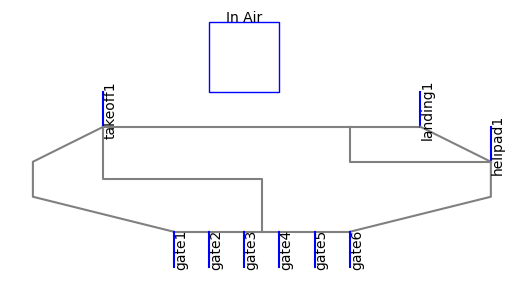

In [13]:
fig, ax = mdl.flows['ground'].show_map()

In [14]:
endresults, mdlhist = prop.nominal(mdl)

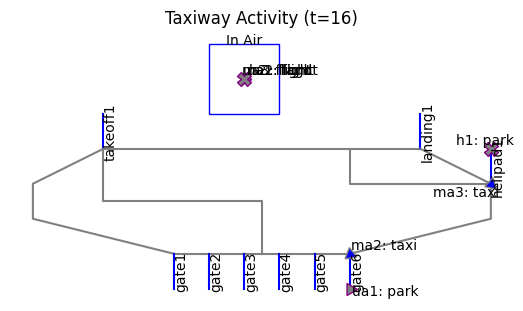

In [15]:
fig, ax=plot_tstep(mdl, mdlhist, 16, show_area_allocation=False, locattr="stage", title="Taxiway Activity ")

In [16]:
fig.savefig("outputs_paper_jcise_dsa/modelactivity.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

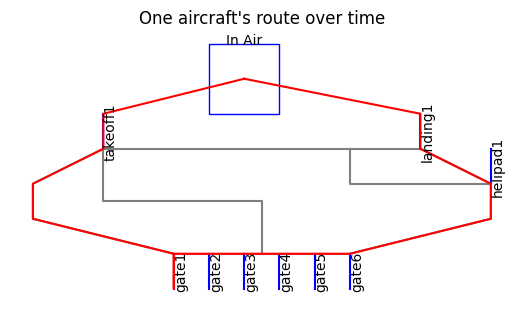

In [17]:
fig, ax = plot_course(mdl, mdlhist, "ma2", title="One aircraft's route over time")

In [18]:
fig.savefig("outputs_paper_jcise_dsa/assetroute.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

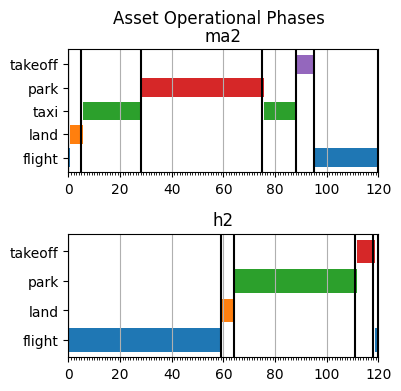

In [19]:
from fmdtools.analyze import phases
phasemaps = phases.from_hist(mdlhist)
phases_to_plot ={"ma2": phasemaps["ma2"], 'h2': phasemaps['h2']}
fig = phases.phaseplot(phases_to_plot, figsize=(4,4), title_padding=-0.02, title="Asset Operational Phases", phase_ticks="both")

In [20]:
fig.savefig("outputs_paper_jcise_dsa/assetmodes.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

## Fault Simulation and Analysis

### Perception Fault - AC Vision Fault

In [21]:
endresults, mdlhist = prop.one_fault(mdl, "ma3", "lost_sight",
                                    to_return={93: {"graph.flows.location":{'include_glob':False, 'with_methods': False}},
                                                    110:{"graph.flows.location":{'include_glob':False, 'with_methods': False}}, 
                                                    20:["graph"], 120:['graph', "classify"]})

0 [0.7500196  0.22596995]
1 [-0.23217534 -0.95440986]


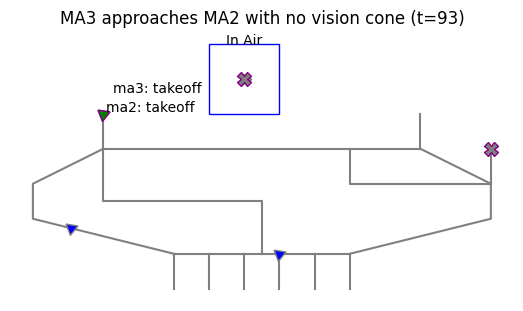

In [22]:
fig, ax = plot_tstep(mdl, mdlhist.faulty, 93,  locattr="stage", assets_to_label=["ma3", "ma2"], areas_to_label=[],
           title="MA3 approaches MA2 with no vision cone ", show_area_allocation=False)

In [23]:
fig.savefig("outputs_paper_jcise_dsa/ac_vision_map.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

In [24]:
endresults.faulty.t120p0.classify #table should also include local, global metrics

num_cycled:                            4
perc_cycled:                         0.5
num_crashed:                           2

In [25]:
endresults

nominal.t20p0.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x0000021513876CF0>
nominal.t93p0.graph.flows.location: <fmdtools.define.flow.multiflow.MultiFlowGraph object at 0x0000021513876F90>
nominal.t110p0.graph.flows.location: <fmdtools.define.flow.multiflow.MultiFlowGraph object at 0x00000215137B20D0>
nominal.t120p0.classify.num_cycled:    8
nominal.t120p0.classify.perc_cycled: 1.0
nominal.t120p0.classify.num_crashed:   0
nominal.t120p0.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x00000215137B2350>
ma3_lost_sight_t0.t20p0.graph: <fmdtools.define.architecture.function.FunctionArchitectureGraph object at 0x0000021513160050>
ma3_lost_sight_t0.t9<fmdtools.define.flow.multiflow.MultiFlowGraph object at 0x0000021513160190>
ma3_lost_sight_t0.t1<fmdtools.define.flow.multiflow.MultiFlowGraph object at 0x0000021512EF5BA0>
ma3_lost_sight_t0.t1                   4
ma3_lost_sight_t0.t1                 0.5
ma3_lost_sight_

In [26]:
endresults.faulty.t93p0.graph.flows.location
endresults.faulty.t93p0.graph.flows.location.set_edge_labels(title="")

In [27]:
#%matplotlib qt
#endresults.t93p0.graph.flows.location.move_nodes()

In [28]:
%matplotlib inline

In [29]:
pos = {'ma1': [-0.51, -0.08], 'ma1_percieved': [-0.88, 0.03], 
       'ma1_closest': [-0.3, 0.12], 'ma2': [-0.66, 0.59], 
       'ma2_percieved': [-0.81, 0.84], 'ma2_closest': [-0.67, 0.26], 
       'ma3': [0.77, 0.49], 'ma3_percieved': [0.81, 0.83], 
       'ma3_closest': [0.51, 0.28], 'ua1': [0.0, 0.62], 
       'ua1_percieved': [0.0, 0.91], 'ua1_closest': [-0.02, 0.34], 
       'ua2': [0.02, -0.64], 'ua2_percieved': [0.0, -0.88], 
       'ua2_closest': [0.04, -0.38], 'ua3': [0.66, -0.48], 
       'ua3_percieved': [0.8, -0.84], 'ua3_closest': [0.42, -0.23], 
       'h1': [0.64, 0.11], 'h1_percieved': [0.93, -0.15], 
       'h1_closest': [0.3, 0.07], 'h2': [-0.69, -0.52], 
       'h2_percieved': [-0.79, -0.85], 'h2_closest': [-0.45, -0.32]}
endresults.faulty.t93p0.graph.flows.location.set_pos(**pos)
endresults.faulty.t93p0.graph.flows.location.set_node_labels(title="shortname")

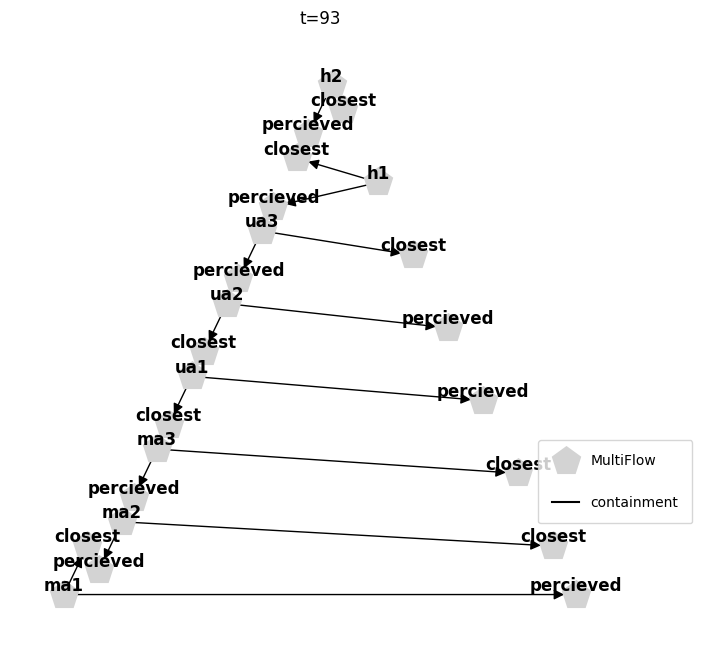

In [30]:
fig, ax = endresults.faulty.t93p0.graph.flows.location.draw(figsize=(8,8), title="t=93", legend_bbox=(0.84,0.27))

In [31]:
fig.savefig("outputs_paper_jcise_dsa/ac_loc_93.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [32]:
#%matplotlib qt
#endresults.t120p0.graph.move_nodes()

In [33]:
%matplotlib inline

In [34]:
pos = {'atc': [-1.0, -0.15], 'ma1': [-0.86, 0.52], 'ma2': [-0.33, 0.95], 
       'ma3': [0.62, -0.78], 'ua1': [-0.66, -0.76], 'ua2': [0.36, 0.94], 
       'ua3': [-0.02, -1.0], 'h1': [0.89, 0.48], 'h2': [1.0, -0.2], 
       'ground': [0.31, -0.26], 'location': [-0.31, -0.24], 'requests': [-0.01, 0.43]}
endresults.faulty.t120p0.graph.set_pos(**pos)

In [35]:
endresults.faulty.t120p0.graph.set_edge_labels(title="")
endresults.faulty.t120p0.graph.set_node_styles(nodetype=dict(FxnBlock=dict(nx_node_size=2000),
                                                    MultiFlow=dict(nx_node_size=2000),
                                                    CommsFlow=dict(nx_node_size=2000)),
                                       degraded={}, faulty={})

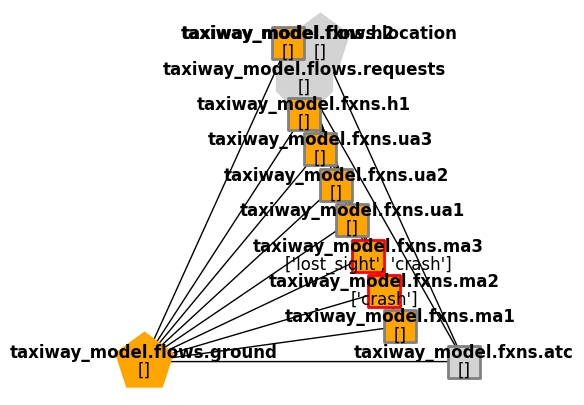

In [36]:
fig, ax = endresults.faulty.t120p0.graph.draw(figsize=(5,5), withlegend=False)

In [37]:
fig.savefig("outputs_paper_jcise_dsa/ac_faultprop_120.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

In [38]:
ind_hist = create_fault_scen_metrics(mdlhist)

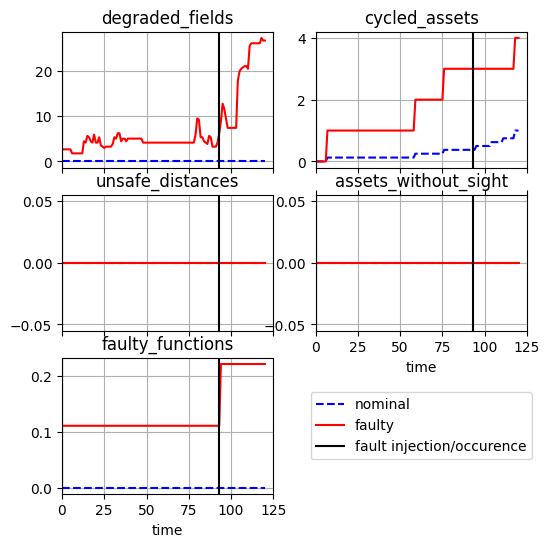

In [39]:
fig, ax = ind_hist.plot_line("degraded_fields",
                             "cycled_assets",
                             "unsafe_distances",
                             "assets_without_sight",
                             "faulty_functions",
                             time_slice=[0,93],
                             time_slice_label = "fault injection/occurence",
                             ylabels={'off-nominal fields':'%'})

In [40]:
fig.savefig("outputs_paper_jcise_dsa/fault_history_ac_vision.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [41]:
final_values = ind_hist.scenario.get_slice(-1)
# final_values

In [42]:
final_res = pd.DataFrame.from_dict({k: [v] for k, v in final_values.items()}, orient='index')
final_res

,0
incorrect_fields,0.000000
assets_without_sight,0.000000
unsafe_distances,0.000000
overbooked_locations,0.000000
incorrect_perception,0.000000
duplicate_land_commands,0.000000
cycled_assets,4.000000
degraded_fields,26.627219
faulty_functions,0.222222
time,120.000000


In [43]:
print(final_res.to_latex())

\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
incorrect_fields & 0.000000 \\
assets_without_sight & 0.000000 \\
unsafe_distances & 0.000000 \\
overbooked_locations & 0.000000 \\
incorrect_perception & 0.000000 \\
duplicate_land_commands & 0.000000 \\
cycled_assets & 4.000000 \\
degraded_fields & 26.627219 \\
faulty_functions & 0.222222 \\
time & 120.000000 \\
\bottomrule
\end{tabular}



### Communications Fault - Poor land command by ATC

In [44]:
from fmdtools.define.flow.multiflow import MultiFlowGraph
from fmdtools.define.flow.commsflow import CommsFlowGraph
ground_args = {'with_root':True, "role_nodes": ['container', 'local']}

# todo: re-add send connections
# 'send_connections':{"asset_area":"asset_area",  "area_allocation":"area_allocation", "asset_assignment":"asset_assignment"}
req_args = {'include_glob': False, "ports_only": True, 'with_methods': False}

endresults, mdlhist = prop.sequence(mdl, faultseq={8:{"atc":["wrong_land_command"]},10:{"ua2":["lost_sight"]}}, 
                                         to_return={10:{"graph.flows.requests":(CommsFlowGraph, req_args)},
                                                         11:{"graph.flows.requests":(CommsFlowGraph, req_args),
                                                            "graph.flows.ground":(MultiFlowGraph, ground_args)},
                                                         19:{"graph.flows.requests":{'include_glob':False, "ports_only":True}},
                                                         20:["graph"], 120:"classify"})

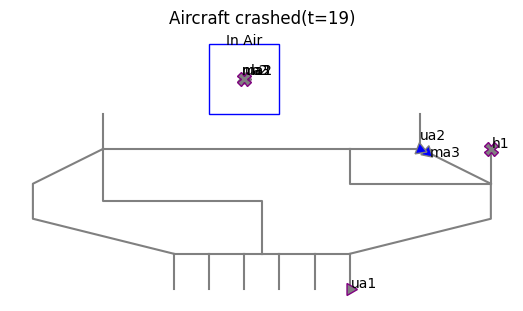

In [45]:
fig, ax = plot_tstep(mdl, mdlhist.faulty, 19, title="Aircraft crashed", areas_to_label=[])

In [46]:
fig.savefig("outputs_paper_jcise_dsa/atc_comms_map.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

In [47]:
endresults.faulty.t120p0.classify

num_cycled:                            4
perc_cycled:                         0.5
num_crashed:                           2

In [48]:
endresults.faulty.t11p0.graph.flows.ground

In [49]:
import networkx as nx

In [50]:
pos = nx.spring_layout(nx.MultiGraph(endresults.faulty.t11p0.graph.flows.ground.g))
endresults.faulty.t11p0.graph.flows.ground.set_pos(**pos)
endresults.faulty.t11p0.graph.flows.ground.set_node_labels(title="last", subtext="indicators")
endresults.faulty.t11p0.graph.flows.ground.set_edge_labels(title="")
endresults.faulty.t11p0.graph.flows.ground.set_node_styles(nodetype={'State':dict(nx_node_size=800),
                                                               'MultiFlow':dict(nx_node_size=800)},
                                                   degraded={}, faulty={})

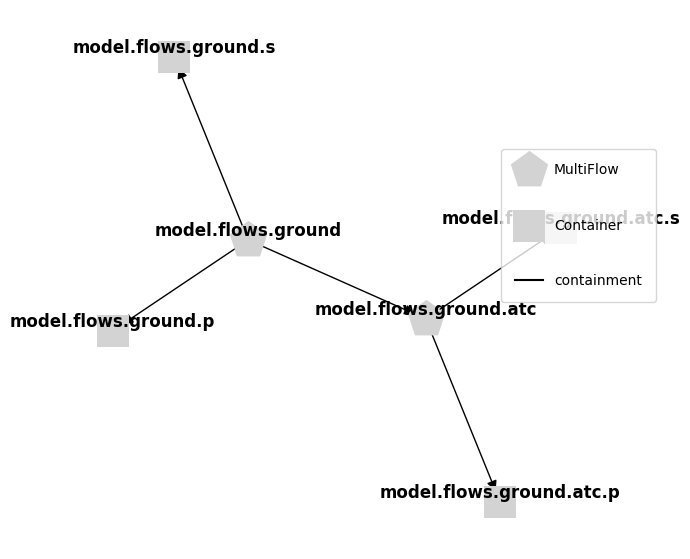

In [51]:
fig, ax = endresults.faulty.t11p0.graph.flows.ground.draw(figsize=(7,7), legend_labelspacing=3, legend_bbox=(0.79,0.6))

In [52]:
fig.savefig("outputs_paper_jcise_dsa/atc_comms_ground_11.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [53]:
pos = nx.spring_layout(nx.MultiGraph(endresults.faulty.t10p0.graph.flows.requests.g), iterations=500)
endresults.faulty.t10p0.graph.flows.requests.set_pos(**pos)

In [54]:
endresults.faulty.t10p0.graph.flows.requests.set_edge_labels(title="")
endresults.faulty.t10p0.graph.flows.requests.set_node_labels(title="shortname")
endresults.faulty.t10p0.graph.flows.requests.set_node_styles(nodetype={'CommsFlow':dict(nx_node_size=900)},
                                                   degraded={}, faulty={})

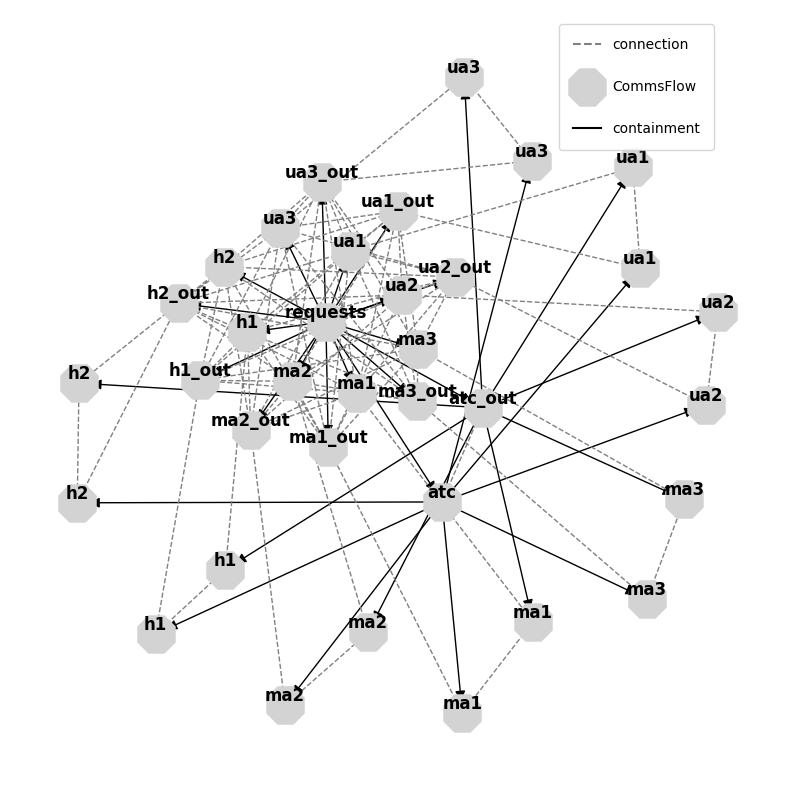

In [55]:
fig, ax = endresults.faulty.t10p0.graph.flows.requests.draw(figsize=(10,10), legend_bbox=(0.7,0.9))

In [56]:
fig.savefig("outputs_paper_jcise_dsa/atc_comms_requests_10.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [57]:
pos = {'atc': [-1.0, -0.22], 'ma1': [-0.86, 0.52], 'ma2': [-0.33, 0.95], 
       'ma3': [0.62, -0.78], 'ua1': [-0.66, -0.76], 'ua2': [0.36, 0.94], 
       'ua3': [-0.02, -1.0], 'h1': [0.89, 0.48], 'h2': [1.0, -0.2], 
       'ground': [0.31, -0.26], 'location': [-0.31, -0.24], 'requests': [-0.01, 0.43]}
endresults.faulty.t20p0.graph.set_pos(**pos)
endresults.faulty.t20p0.graph.set_edge_labels(title="")
endresults.faulty.t20p0.graph.set_node_labels(title="shortname")
endresults.faulty.t20p0.graph.set_node_styles(nodetype=dict(FxnBlock=dict(nx_node_size=2000),
                                                     MultiFlow=dict(nx_node_size=2000),
                                                     CommsFlow=dict(nx_node_size=2000)),
                                       degraded={}, faulty={})

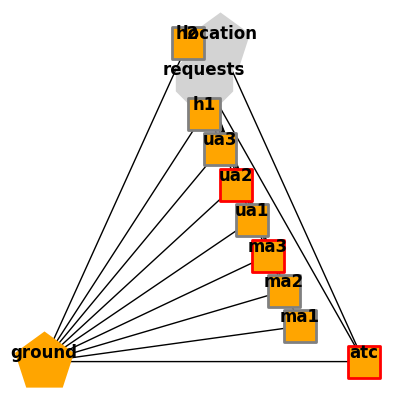

In [58]:
fig, ax = endresults.faulty.t20p0.graph.draw(withlegend=False, figsize=(5,5))

In [59]:
fig.savefig("outputs_paper_jcise_dsa/atc_comms_resgraph.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

In [60]:
ind_hist = create_fault_scen_metrics(mdlhist)

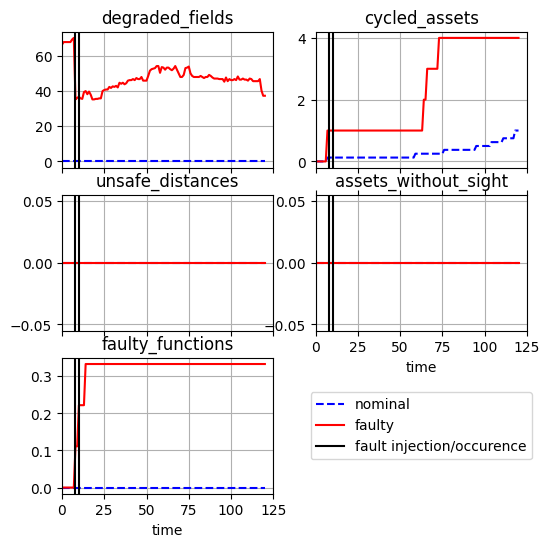

In [61]:
fig, ax = ind_hist.plot_line("degraded_fields",
                            "cycled_assets",
                            "unsafe_distances",
                            "assets_without_sight",
                            "faulty_functions",
                            time_slice=[8, 10],
                            time_slice_label = "fault injection/occurence",
                            ylabels={'off-nominal fields':'%'})

In [62]:
fig.savefig("outputs_paper_jcise_dsa/fault_history_atc_comms.eps", format="eps", bbox_inches = 'tight', pad_inches = 0)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [63]:
final_values = ind_hist.scenario.get_slice(-1)
final_values

incorrect_fields:                      0
assets_without_sight:                  0
unsafe_distances:                      0
overbooked_locations:                  1
incorrect_perception:                  0
duplicate_land_commands:               0
cycled_assets:                         4
degraded_fields:       37.27810650887574
faulty_functions:     0.3333333333333333
time:                              120.0

In [64]:
final_res = pd.DataFrame.from_dict({k: [v] for k, v in final_values.items()}, orient='index')
final_res

,0
incorrect_fields,0.000000
assets_without_sight,0.000000
unsafe_distances,0.000000
overbooked_locations,1.000000
incorrect_perception,0.000000
duplicate_land_commands,0.000000
cycled_assets,4.000000
degraded_fields,37.278107
faulty_functions,0.333333
time,120.000000


In [65]:
print(final_res.to_latex())

\begin{tabular}{lr}
\toprule
 & 0 \\
\midrule
incorrect_fields & 0.000000 \\
assets_without_sight & 0.000000 \\
unsafe_distances & 0.000000 \\
overbooked_locations & 1.000000 \\
incorrect_perception & 0.000000 \\
duplicate_land_commands & 0.000000 \\
cycled_assets & 4.000000 \\
degraded_fields & 37.278107 \\
faulty_functions & 0.333333 \\
time & 120.000000 \\
\bottomrule
\end{tabular}

